# Regresión Lineal Múltiple
## Predicción del Puntaje de Riesgo de Diabetes

Este notebook implementa un modelo de **regresión lineal múltiple** para predecir el `diabetes_risk_score` a partir de características demográficas, clínicas y de estilo de vida.

**Dataset:** [Diabetes Health Indicators Dataset - Kaggle](https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data)

---

## 1. Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

print('Librerías importadas correctamente ✓')

Librerías importadas correctamente ✓


## 2. Carga y Selección de Datos

Se carga el archivo CSV y se seleccionan las columnas relevantes.

| Columna | Nombre | Descripción |
|---------|--------|-------------|
| 0  | `age`                              | Edad del paciente |
| 8  | `physical_activity_minutes_per_week` | Minutos de actividad física por semana |
| 9  | `diet_score`                       | Puntuación de la calidad de la dieta |
| 12 | `family_history_diabetes`          | Antecedentes familiares (0=No, 1=Sí) |
| 15 | `bmi`                              | Índice de masa corporal |
| 16 | `waist_to_hip_ratio`               | Relación cintura-cadera |
| 17 | `systolic_bp`                      | Presión arterial sistólica |
| 21 | `hdl_cholesterol`                  | Colesterol HDL |
| 23 | `triglycerides`                    | Triglicéridos |
| 24 | `glucose_fasting`                  | Glucosa en ayunas |
| 25 | `glucose_postprandial`             | Glucosa postprandial |
| 26 | `insulin_level`                    | Nivel de insulina |
| 27 | `hba1c`                            | Hemoglobina glucosilada (HbA1c) |

**Variable objetivo (col. 28):** `diabetes_risk_score`

In [ ]:
data = np.genfromtxt('../Database/1_diabetes_dataset.csv', delimiter=',', skip_header=1)

X = data[:, [0, 8, 9, 12, 15, 16, 17, 21, 23, 24, 25, 26, 27]]
y = data[:, 28]

print('{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>10s}'.format(
    'age', 'phys', 'diet', 'fam_h', 'bmi', 'whr', 'sys_bp', 'hdl', 'trig', 'gluc_f', 'gluc_p', 'insulin', 'hba1c', 'risk_score'))
print('-' * 114)
for i in range(10):
    print('{:8.0f}{:8.0f}{:8.1f}{:8.0f}{:8.1f}{:8.2f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.2f}{:8.2f}{:10.1f}'.format(
        X[i, 0],   # age
        X[i, 1],   # physical_activity_minutes_per_week
        X[i, 2],   # diet_score
        X[i, 3],   # family_history_diabetes
        X[i, 4],   # bmi
        X[i, 5],   # waist_to_hip_ratio
        X[i, 6],   # systolic_bp
        X[i, 7],   # hdl_cholesterol
        X[i, 8],   # triglycerides
        X[i, 9],   # glucose_fasting
        X[i, 10],  # glucose_postprandial
        X[i, 11],  # insulin_level
        X[i, 12],  # hba1c
        y[i]       # diabetes_risk_score
    ))

     age    phys    diet   fam_h     bmi     whr  sys_bp     hdl    trig  gluc_f  gluc_p insulin   hba1crisk_score
------------------------------------------------------------------------------------------------------------------
      58     215     5.7       0    30.5    0.89     134      41     145     136     236    6.36    8.18      29.6
      48     143     6.7       0    23.1    0.80     129      55      30      93     150    2.00    5.63      23.0
      60      57     6.4       1    22.2    0.81     115      66      36     118     195    5.07    7.51      44.7
      74      49     3.4       0    26.8    0.88     120      50     140     139     253    5.28    9.03      38.2
      46     109     7.2       0    21.2    0.78      92      52     160     137     184   12.74    7.20      23.5
      46     124     9.0       0    26.1    0.85      95      61     179     100     133    8.77    6.03      23.5
      75      53     9.2       0    25.1    0.88     129      46     155     101

## 3. Normalización de Características

Se aplica **estandarización Z-score** para escalar las características y evitar que variables con grandes magnitudes dominen el modelo.

$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ la desviación estándar de cada característica.

In [3]:
def  featureNormalize(X): # Conjunto de columnas o matriz

    X_norm = X.copy() # Travajamos sobre una copy de x para no daniar la original
    mu = np.zeros(X.shape[1]) # Shape[0]numero de filas, shape[1]columnas , mu = media x 
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0) # axis 1 fias ,axis 0 columnas 
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [4]:
X_norm, mu, sigma = featureNormalize(X)

## 4. División en Entrenamiento y Prueba

Se divide el dataset en **80% entrenamiento** y **20% prueba**.

In [5]:
x_train, x_test, y_train, y_test =train_test_split(X_norm, y,test_size=0.2, shuffle=False)
X_norm=x_train
y=y_train

## 5. Visualización: Características vs. Variable Objetivo

Se grafican las 13 características (normalizadas) contra el `diabetes_risk_score` para explorar visualmente las relaciones lineales.

In [6]:
# Nombres de las características (basado en tus comentarios)
feature_names = [
    'age', 'physical_activity', 'diet_score', 'family_history', 'bmi', 'waist_to_hip', 'systolic_bp', 'hdl', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]
def plotData(x_feature, y, xlabel, ylabel):
    fig = plt.figure(figsize=(10, 6))
    plt.plot(x_feature, y, 'ro', mec='k', alpha=0.5, markersize=1)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    return fig

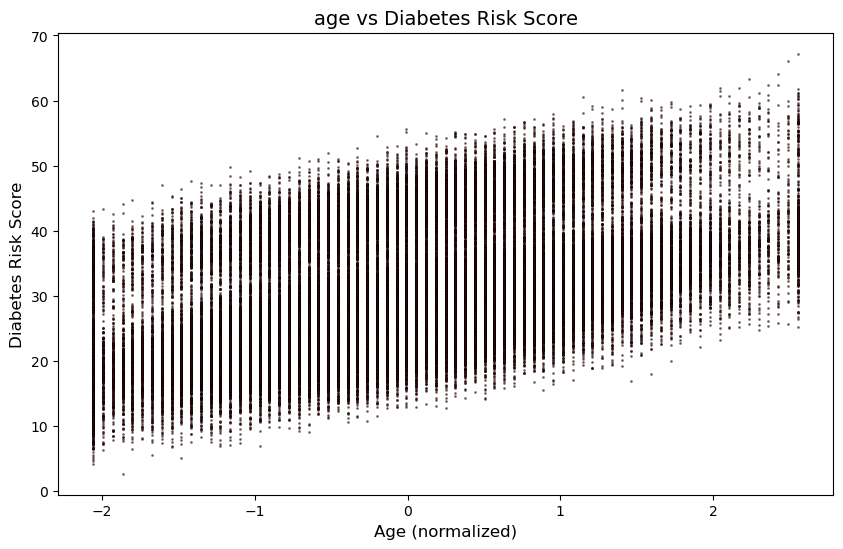

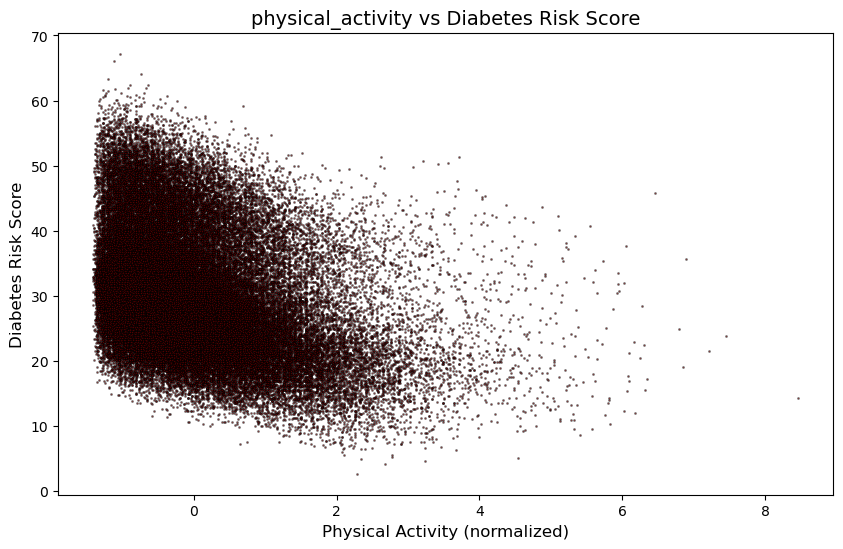

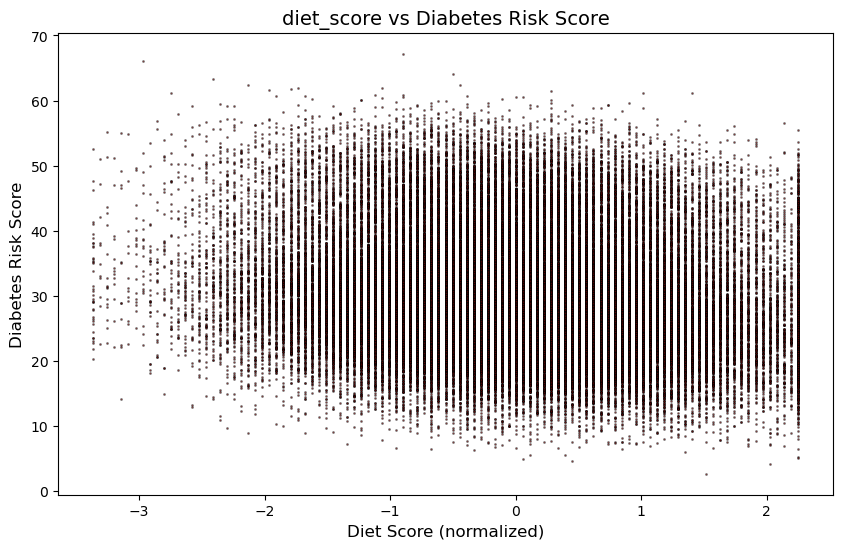

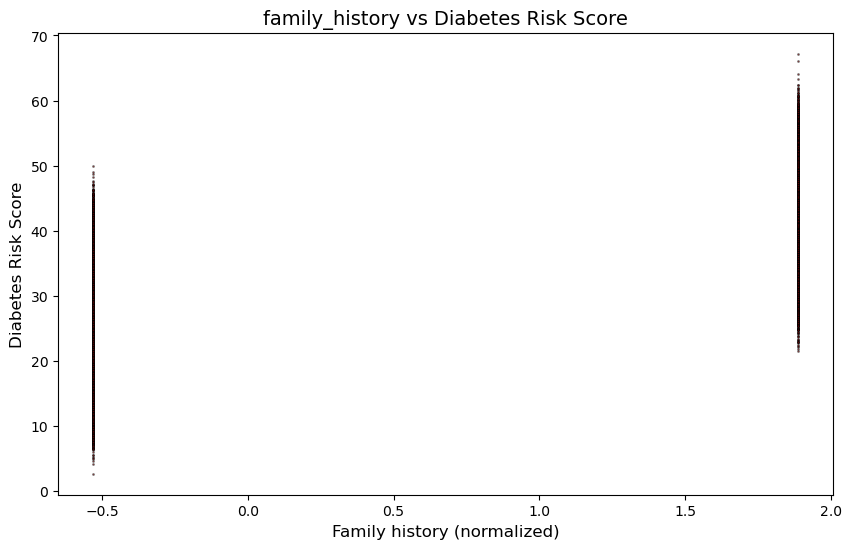

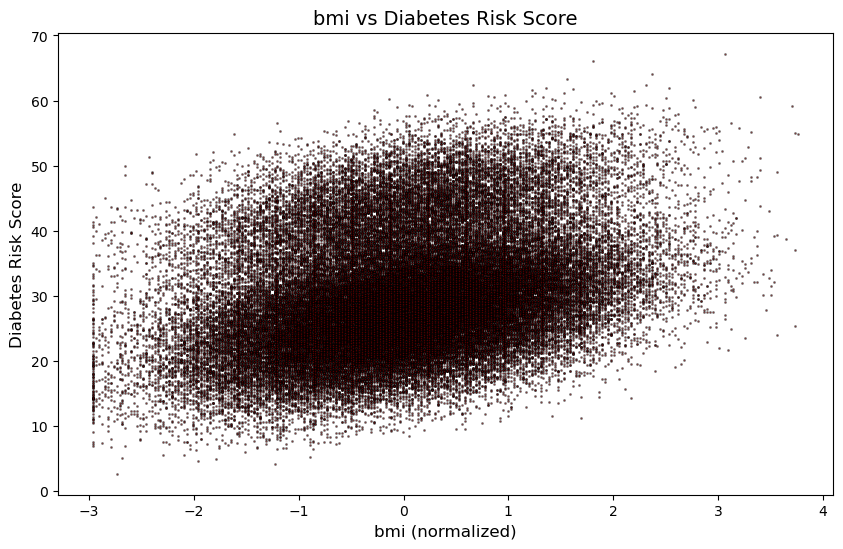

In [7]:
# Definir etiquetas para las primeras características
xlabel1 = 'Age (normalized)'
xlabel2 = 'Physical Activity (normalized)'
xlabel3 = 'Diet Score (normalized)'
xlabel4 = 'Family history (normalized)'
xlabel5 = 'bmi (normalized)'
ylabel = 'Diabetes Risk Score'

plotData(X_norm[:, 0], y, xlabel1, ylabel)
plt.title(f'{feature_names[0]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 1], y, xlabel2, ylabel)
plt.title(f'{feature_names[1]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 2], y, xlabel3, ylabel)
plt.title(f'{feature_names[2]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 3], y, xlabel4, ylabel)
plt.title(f'{feature_names[3]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 4], y, xlabel5, ylabel)
plt.title(f'{feature_names[4]} vs {ylabel}', fontsize=14)
plt.show()


## 6. Fundamentos del Modelo

### Modelo de Regresión Lineal Múltiple

$$y = h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n + \epsilon$$

- $y$: variable dependiente (`diabetes_risk_score`)
- $x_i$: variables independientes (características)
- $\theta_i$: coeficientes del modelo (a estimar)
- $\epsilon$: error aleatorio

### Función de Costo (MSE)

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

## 7. Entrenamiento del Modelo

### 7.1 Preparación: Agregar término de sesgo ($\theta_0$)

Se agrega una columna de unos al inicio de $X$ para representar el término independiente $\theta_0$.

In [8]:
# Agregar columna de unos para el término de sesgo (beta_0)
m = y.size
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

### 7.2 Función de Costo y Descenso por Gradiente

In [9]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [10]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []
    P_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [11]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 8000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

theta calculado por el descenso por el gradiente: [ 3.02101807e+01  4.20837522e+00 -2.94655066e+00 -8.93902956e-01
  6.55155235e+00  1.42977158e+00  1.27070221e-01  1.00771681e-01
 -9.85404561e-01  5.75170370e-01  1.97412885e-01 -4.45269621e-02
  2.06018000e-02 -2.98435579e-02]


### 7.3 Curva de Aprendizaje

Text(0.5, 1.0, 'Convergencia del Descenso por Gradiente')

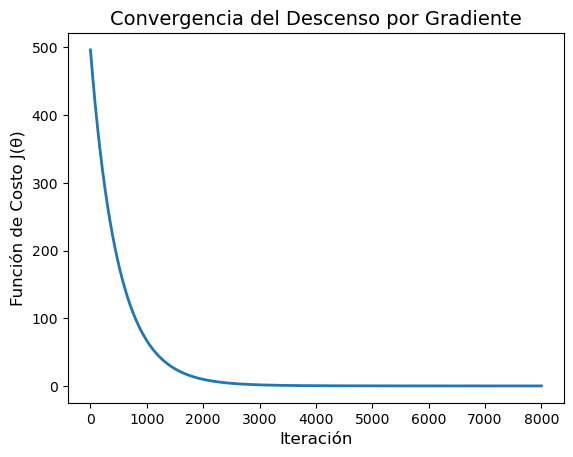

In [12]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Función de Costo J(θ)', fontsize=12)
plt.title('Convergencia del Descenso por Gradiente', fontsize=14)

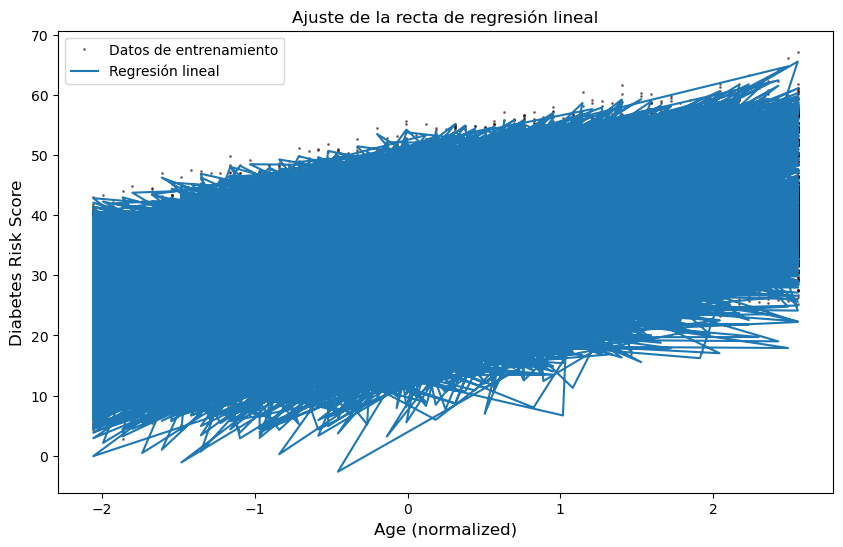

In [13]:
# Mostrar resultados de entrenamiento
plotData(X_norm[:,0], y, xlabel1, ylabel) # Graficar datos de entrenamiento
plt.plot(X_norm[:,0], np.dot(X, theta), '-') # Graficar la linea de regresion
plt.title('Ajuste de la recta de regresión lineal')
plt.legend(['Datos de entrenamiento', 'Regresión lineal'])

## 8. Evaluación del Modelo

Se evalúa el modelo sobre el conjunto de prueba usando:
- **MSE** (Error Cuadrático Medio)

In [14]:
# Procesar y predecir con datos de prueba
m_test = y_test.size
x_test_pre = np.concatenate([np.ones((m_test, 1)), x_test], axis=1)
Y_pre = np.dot(x_test_pre, theta)
resultados = pd.DataFrame({
    'Valor_Real': y_test,
    'Prediccion': Y_pre
})
print("\nPrimeras filas del DataFrame 'resultados':")
print(resultados.head(10))


Primeras filas del DataFrame 'resultados':
   Valor_Real  Prediccion
0        18.8   20.236635
1        26.4   26.493646
2        25.9   25.999303
3        17.5   17.828187
4        33.7   34.667913
5        19.8   18.718239
6        31.9   31.607173
7        17.0   19.270396
8        54.6   53.690050
9        21.4   22.275792


## 9. Predicción con Nuevos Datos

Para predecir sobre un nuevo paciente se deben aplicar los mismos valores de `mu` y `sigma` calculados durante el entrenamiento.

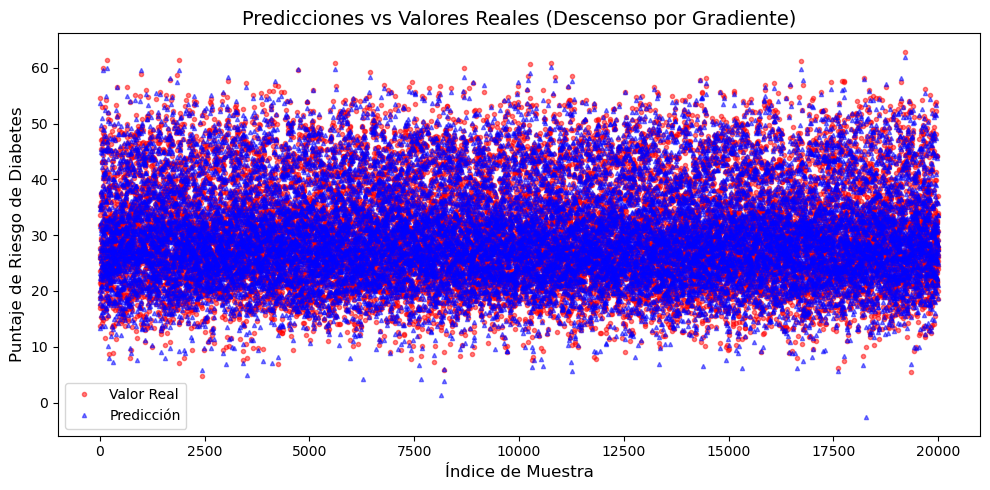

In [15]:
# Graficar Predicciones vs Valores Reales
plt.figure(figsize=(10, 5))
plt.plot(resultados['Valor_Real'].values, 'ro', label='Valor Real', alpha=0.5, markersize=3)
plt.plot(resultados['Prediccion'].values, 'b^', label='Predicción', alpha=0.5, markersize=3)
plt.xlabel('Índice de Muestra', fontsize=12)
plt.ylabel('Puntaje de Riesgo de Diabetes', fontsize=12)
plt.title('Predicciones vs Valores Reales (Descenso por Gradiente)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


<a id="section7"></a>
### 10 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [16]:
data = np.genfromtxt('../Database/1_diabetes_dataset.csv', delimiter=',', skip_header=1)

X = data[:, [0, 8, 9, 12, 15, 16, 17, 21, 23, 24, 25, 26, 27]]
y = data[:, 28]

In [17]:
# División en entrenamiento/prueba (sobre datos SIN normalizar)
x_train_n, x_test_n, y_train_n, y_test_n = train_test_split(X, y, test_size=0.2, shuffle=False)
X_ne = x_train_n   # X para ecuación normal (sin normalizar)
y_ne = y_train_n
x_test_ne = x_test_n
y_test_ne = y_test_n


In [18]:
# Agregar columna de unos para el término de sesgo (beta_0)
m_ne = y_ne.size
X_ne_b = np.concatenate([np.ones((m_ne, 1)), X_ne], axis=1)


In [19]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [20]:
# Calcula los parámetros con la ecuación de la normal
theta_normal = normalEqn(X_ne_b, y_ne)

# Muestra los resultados obtenidos a partir de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal:')
feature_labels = ['bias', 'age', 'physical_activity', 'diet_score', 'family_history',
                  'bmi', 'waist_to_hip', 'systolic_bp', 'hdl', 'triglycerides',
                  'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']
for label, t in zip(feature_labels, theta_normal):
    print(f'  {label:25s}: {t:.6f}')

# ------------------------------------------------------------------
# Predicción para un paciente de ejemplo (datos crudos, sin normalizar)
# Paciente: 55 años, 120 min/sem actividad, dieta 6.0, sin historial familiar,
#           BMI 28.0, WHR 0.85, sys_bp 125, HDL 50, trig 130,
#           gluc_fasting 110, gluc_post 170, insulina 8.0, HbA1c 6.5
# ------------------------------------------------------------------
paciente_raw = np.array([1, 55, 120, 6.0, 0, 28.0, 0.85, 125, 50, 130, 110, 170, 8.0, 6.5])
risk_score_pred = np.dot(paciente_raw, theta_normal)
print(f'\nPuntaje de riesgo de diabetes predicho para el paciente de ejemplo'
      f' (ecuación de la normal): {risk_score_pred:.2f}')


Theta calculado a partir de la ecuación de la normal:
  bias                     : 11.620135
  age                      : 0.276582
  physical_activity        : -0.035123
  diet_score               : -0.501421
  family_history           : 15.952391
  bmi                      : 0.447353
  waist_to_hip             : 0.004672
  systolic_bp              : 0.000361
  hdl                      : -0.095614
  triglycerides            : 0.012825
  glucose_fasting          : 0.004802
  glucose_postprandial     : 0.000297
  insulin_level            : 0.000464
  hba1c                    : -0.009074

Puntaje de riesgo de diabetes predicho para el paciente de ejemplo (ecuación de la normal): 29.59


### Evaluación y Visualización (Ecuación de la Normal)

Se predice sobre el conjunto de prueba y se comparan los resultados con los valores reales, de la misma forma que se hizo con el descenso por gradiente.

In [21]:
# Predicciones sobre el conjunto de prueba
m_test_ne = y_test_ne.size
x_test_pre_ne = np.concatenate([np.ones((m_test_ne, 1)), x_test_ne], axis=1)
Y_pre_ne = np.dot(x_test_pre_ne, theta_normal)

resultados_normal = pd.DataFrame({
    'Valor_Real': y_test_ne,
    'Prediccion': Y_pre_ne
})

# MSE
mse_normal = np.mean((resultados_normal['Valor_Real'] - resultados_normal['Prediccion'])**2)
print(f'MSE (Ecuación de la Normal): {mse_normal:.4f}')
print('\nPrimeras filas de resultados:')
print(resultados_normal.head(10))


MSE (Ecuación de la Normal): 1.0021

Primeras filas de resultados:
   Valor_Real  Prediccion
0        18.8   20.058025
1        26.4   26.366221
2        25.9   26.004817
3        17.5   17.902044
4        33.7   34.522130
5        19.8   18.776715
6        31.9   31.447546
7        17.0   19.143750
8        54.6   53.840393
9        21.4   21.946882


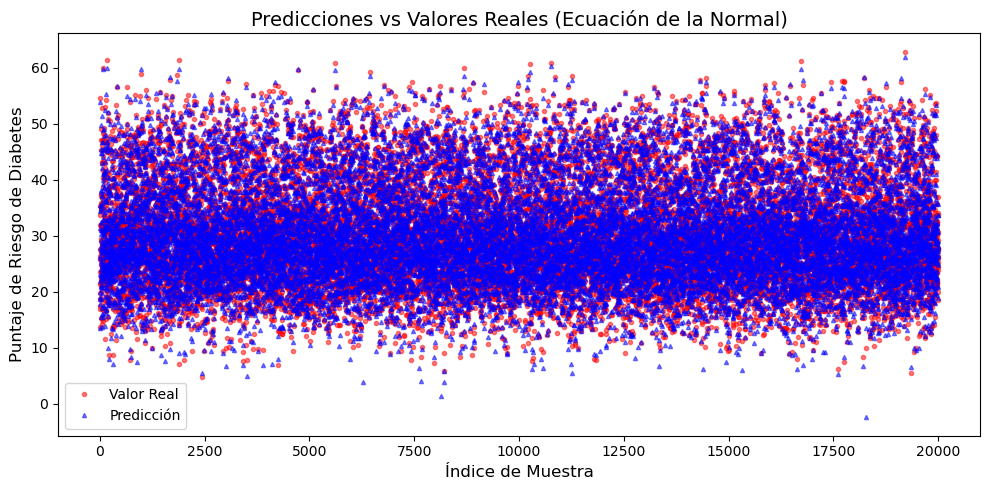

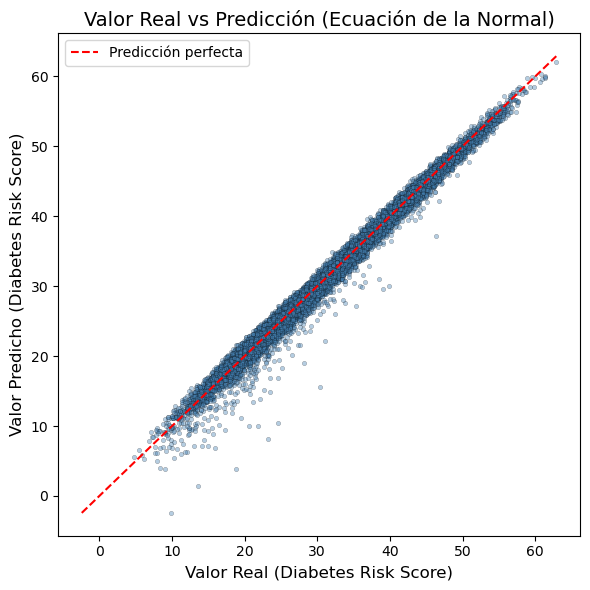

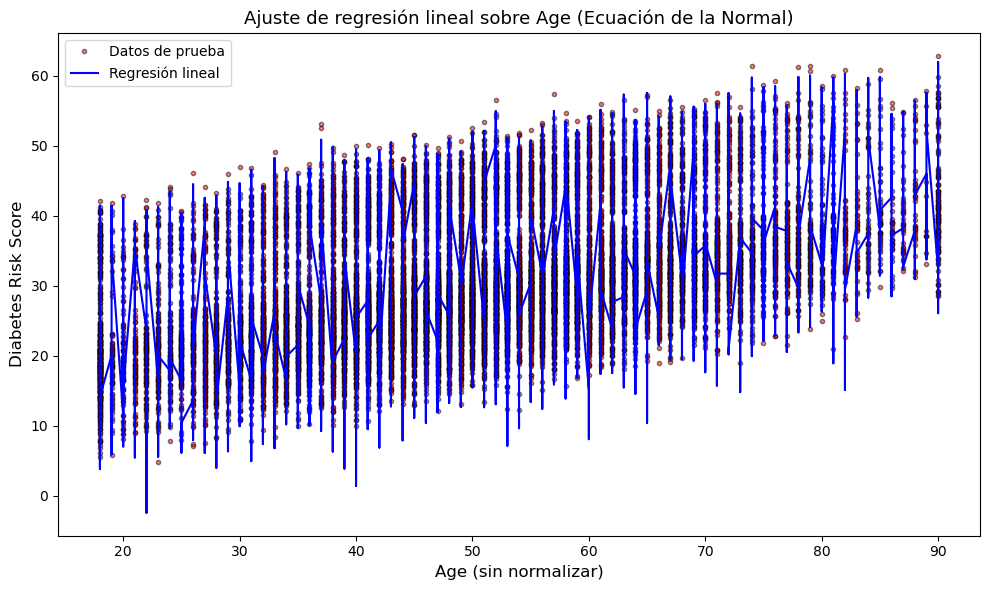

In [22]:
# --- Gráfico 1: Predicciones vs Valores Reales ---
plt.figure(figsize=(10, 5))
plt.plot(resultados_normal['Valor_Real'].values, 'ro', label='Valor Real', alpha=0.5, markersize=3)
plt.plot(resultados_normal['Prediccion'].values, 'b^', label='Predicción', alpha=0.5, markersize=3)
plt.xlabel('Índice de Muestra', fontsize=12)
plt.ylabel('Puntaje de Riesgo de Diabetes', fontsize=12)
plt.title('Predicciones vs Valores Reales (Ecuación de la Normal)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# --- Gráfico 2: Scatter Valor Real vs Predicción ---
plt.figure(figsize=(6, 6))
plt.scatter(resultados_normal['Valor_Real'], resultados_normal['Prediccion'],
            alpha=0.4, s=10, color='steelblue', edgecolors='k', linewidths=0.3)
min_val = min(resultados_normal['Valor_Real'].min(), resultados_normal['Prediccion'].min())
max_val = max(resultados_normal['Valor_Real'].max(), resultados_normal['Prediccion'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Predicción perfecta')
plt.xlabel('Valor Real (Diabetes Risk Score)', fontsize=12)
plt.ylabel('Valor Predicho (Diabetes Risk Score)', fontsize=12)
plt.title('Valor Real vs Predicción (Ecuación de la Normal)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# --- Gráfico 3: Ajuste sobre la característica Age ---
sort_idx = np.argsort(x_test_ne[:, 0])
x_test_ne_sorted = x_test_ne[sort_idx]
x_test_pre_sorted = np.concatenate([np.ones((m_test_ne, 1)), x_test_ne_sorted], axis=1)
y_pred_sorted = np.dot(x_test_pre_sorted, theta_normal)

plt.figure(figsize=(10, 6))
plt.plot(x_test_ne[:, 0], y_test_ne, 'ro', mec='k', alpha=0.5, markersize=3, label='Datos de prueba')
plt.plot(x_test_ne_sorted[:, 0], y_pred_sorted, '-', color='blue', lw=1.5, label='Regresión lineal')
plt.xlabel('Age (sin normalizar)', fontsize=12)
plt.ylabel('Diabetes Risk Score', fontsize=12)
plt.title('Ajuste de regresión lineal sobre Age (Ecuación de la Normal)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()
